In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from scipy import stats

In [2]:
mlb_pitchers = pd.read_csv('All Pitchers Cleaned.csv')
mlb_pitchers

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,BF,ERA+,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame
0,Cy Young,1890,23,1911,44,21,511,315,0.619,826,...,29565,138,2.84,1.130,8.7,0.2,1.5,3.4,2.30,1
1,Pud Galvin,1875,18,1892,35,17,365,310,0.541,675,...,25415,107,2.96,1.191,9.6,0.2,1.1,2.7,2.43,1
2,Walter Johnson,1907,19,1927,39,20,417,279,0.599,696,...,23415,147,2.38,1.061,7.5,0.1,2.1,5.3,2.57,1
3,Phil Niekro,1964,25,1987,48,23,318,274,0.537,592,...,22677,115,3.62,1.268,8.4,0.8,3.0,5.6,1.85,1
4,Nolan Ryan,1966,19,1993,46,27,324,292,0.526,616,...,22575,112,2.97,1.247,6.6,0.5,4.7,9.5,2.04,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,1919,23,1928,32,9,49,80,0.380,129,...,4453,90,3.89,1.518,10.3,0.3,3.4,2.8,0.82,0
1211,Sammy Ellis,1962,21,1969,28,7,63,58,0.521,121,...,4296,88,3.90,1.340,8.7,1.1,3.4,6.1,1.79,0
1212,Lil Stoner,1922,23,1931,32,9,50,57,0.467,107,...,4466,87,4.13,1.548,10.6,0.6,3.4,2.7,0.80,0
1213,Johnny Humphries,1938,23,1946,31,8,52,63,0.452,115,...,4342,97,3.80,1.394,9.2,0.4,3.4,2.8,0.85,0


# Stratified KFold

In [3]:
dtree = DecisionTreeClassifier(random_state=42)

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [4]:
# Define K-Fold cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Define model
dtree = DecisionTreeClassifier(random_state=42)

# Define GridSearchCV with KFold
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=kf,                    # pass KFold object here
    scoring='recall',
    n_jobs=-1
)

# Fit on your training data
grid_search.fit(X_train, y_train)

# Best model
#best_model = grid_search.best_estimator_
dtree_best = grid_search.best_estimator_
dtree_best.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [5]:
# Define the same KFold strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get out-of-fold predictions using the tuned model
y_pred_all_best = cross_val_predict(dtree_best, X, y, cv=kf)

# Get predicted probabilities
y_proba_all_best = cross_val_predict(dtree_best, X, y, cv=kf, method='predict_proba')

# Regular predictions
y_pred_all_best = cross_val_predict(dtree_best, X, y, cv=kf)

# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all_best])
confidence_scores = y_proba_all_best[np.arange(len(y_proba_all_best)), y_pred_indices]

# Build results dataframe
dtree_gs_results = pd.DataFrame()
dtree_gs_results['Player'] = mlb_pitchers['Player']
dtree_gs_results['Hall of Fame'] = y
dtree_gs_results['Prediction'] = y_pred_all_best
dtree_gs_results['Prediction Correct'] = (dtree_gs_results['Hall of Fame'] == dtree_gs_results['Prediction']).astype(int)
dtree_gs_results['Prediction Confidence'] = confidence_scores
dtree_gs_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,0,0,1.0
1,Pud Galvin,1,0,0,1.0
2,Walter Johnson,1,1,1,1.0
3,Phil Niekro,1,1,1,1.0
4,Nolan Ryan,1,1,1,1.0
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.0
1211,Sammy Ellis,0,0,1,1.0
1212,Lil Stoner,0,0,1,1.0
1213,Johnny Humphries,0,0,1,1.0


Accuracy : 0.9564 [TP / N]         Best: 1, Worst: 0
           Percentage of all predictions that were correct.
Precision: 0.6986 [TP / (TP + FP)] Best: 1, Worst: 0
           Percent of Positive predictions that were correct. Minimizes false positives.
Recall   : 0.6220 [TP / (TP + FN)] Best: 1, Worst: 0
           Percent of Positive instances that were identified as such. Minimizes false negatives.
F1 Score : 0.6581 [2PR / (P + R)]  Best: 1, Worst: 0
           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.
ROC AUC  : 0.8013                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


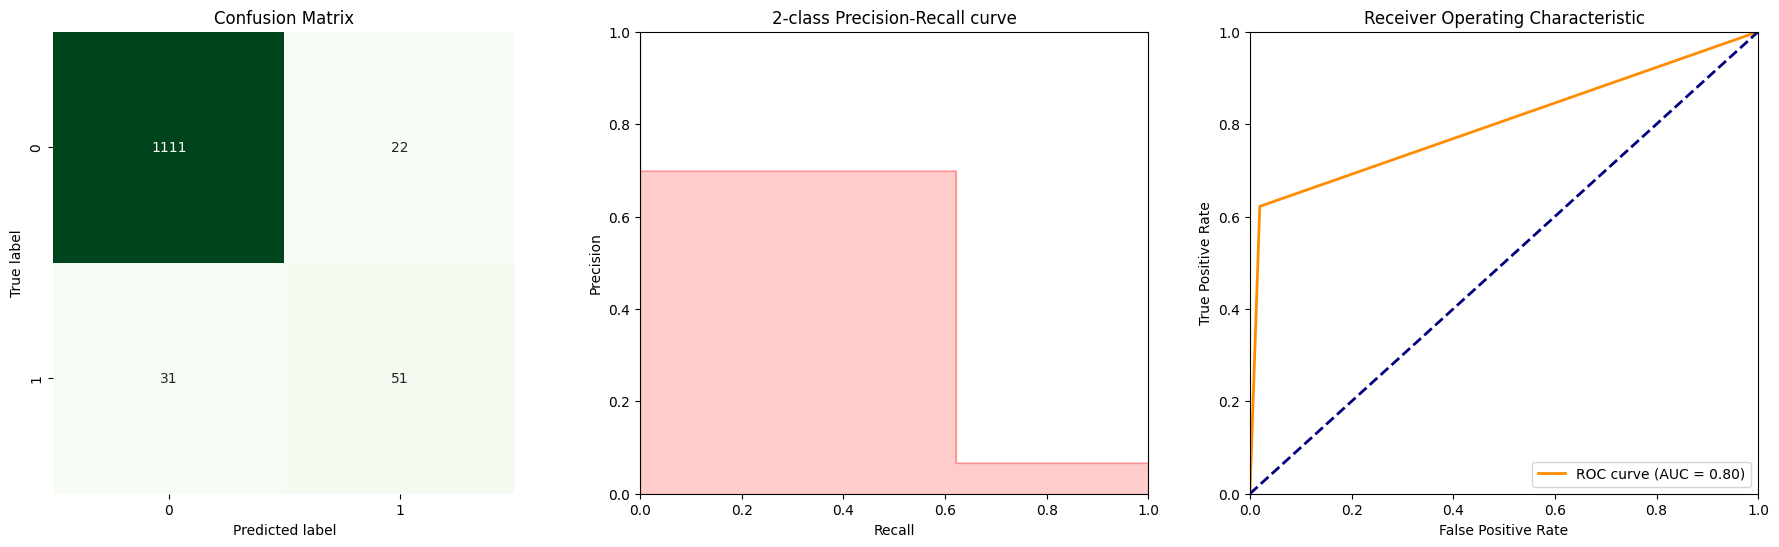

In [6]:
# Run this cell to generate a classification report with metrics and visuals

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of Positive instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [2PR / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.')

    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix (no .T)
    sns.heatmap(mat, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()


show_summary_report(y, y_pred_all_best)

# GridSearch V1

In [3]:
dtree = DecisionTreeClassifier(random_state=42)

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [4]:
# Define K-Fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Define model
dtree = DecisionTreeClassifier(random_state=42)

# Define GridSearchCV with KFold
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=kf,                    # pass KFold object here
    scoring='f1',
    n_jobs=-1
)

# Fit on your training data
grid_search.fit(X_train, y_train)

# Best model
#best_model = grid_search.best_estimator_
dtree_best = grid_search.best_estimator_
dtree_best.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [ ]:
dtree_best = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                       min_samples_split=5, random_state=42, class_weight='balanced')
dtree_best.fit(X_train, y_train)

In [5]:
# Define the same KFold strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get out-of-fold predictions using the tuned model
y_pred_all_best = cross_val_predict(dtree_best, X, y, cv=kf)

# Get predicted probabilities
y_proba_all_best = cross_val_predict(dtree_best, X, y, cv=kf, method='predict_proba')

# Regular predictions
y_pred_all_best = cross_val_predict(dtree_best, X, y, cv=kf)

# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all_best])
confidence_scores = y_proba_all_best[np.arange(len(y_proba_all_best)), y_pred_indices]

# Build results dataframe
dtree_gs_results = pd.DataFrame()
dtree_gs_results['Player'] = mlb_pitchers['Player']
dtree_gs_results['Hall of Fame'] = y
dtree_gs_results['Prediction'] = y_pred_all_best
dtree_gs_results['Prediction Correct'] = (dtree_gs_results['Hall of Fame'] == dtree_gs_results['Prediction']).astype(int)
dtree_gs_results['Prediction Confidence'] = confidence_scores
dtree_gs_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,0,0,1.0
1,Pud Galvin,1,0,0,1.0
2,Walter Johnson,1,1,1,1.0
3,Phil Niekro,1,1,1,1.0
4,Nolan Ryan,1,1,1,1.0
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.0
1211,Sammy Ellis,0,0,1,1.0
1212,Lil Stoner,0,0,1,1.0
1213,Johnny Humphries,0,0,1,1.0


Accuracy : 0.9531 [TP / N]         Best: 1, Worst: 0
           Percentage of all predictions that were correct.
Precision: 0.6712 [TP / (TP + FP)] Best: 1, Worst: 0
           Percent of Positive predictions that were correct. Minimizes false positives.
Recall   : 0.5976 [TP / (TP + FN)] Best: 1, Worst: 0
           Percent of Positive instances that were identified as such. Minimizes false negatives.
F1 Score : 0.6323 [2PR / (P + R)]  Best: 1, Worst: 0
           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.
ROC AUC  : 0.7882                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


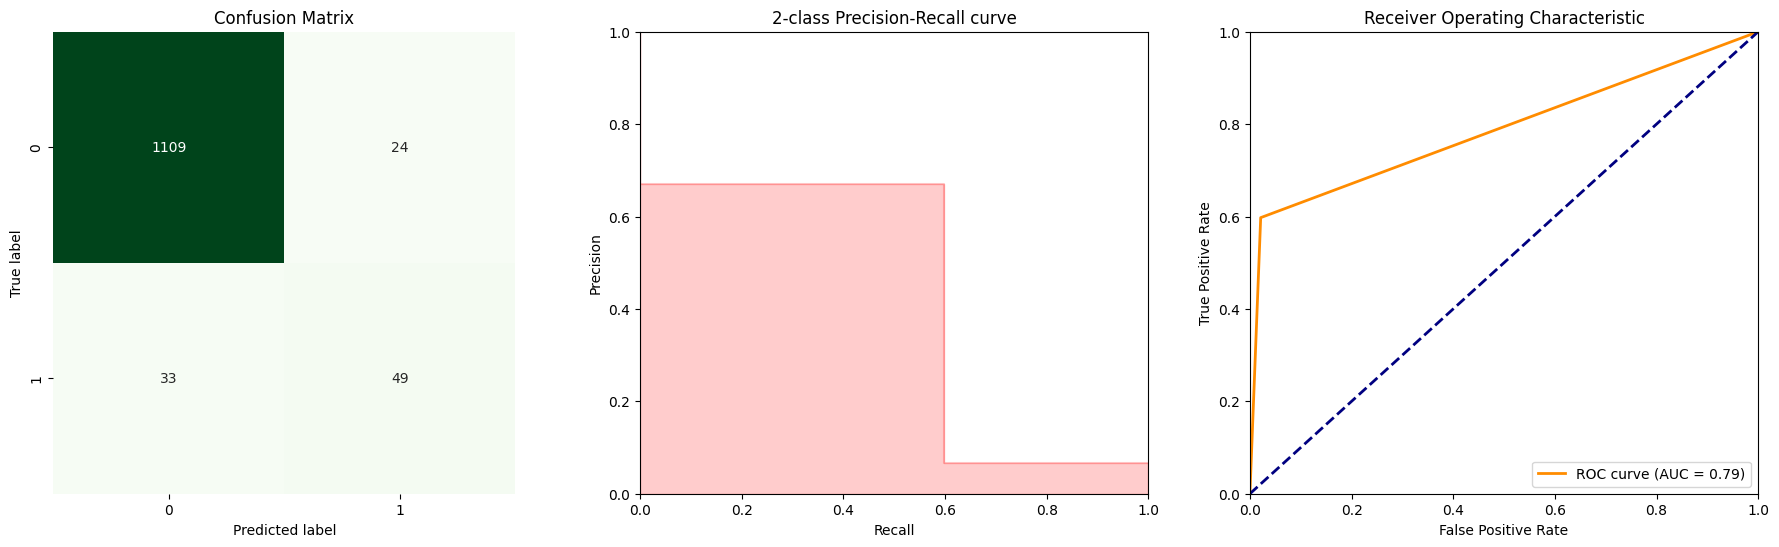

In [6]:
# Run this cell to generate a classification report with metrics and visuals

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of Positive instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [2PR / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.')

    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix (no .T)
    sns.heatmap(mat, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()


show_summary_report(y, y_pred_all_best)

In [7]:
dtree_gs_results.to_csv('Results DTree with GS.csv', index=False)

# ParamGrids

# Old version, without GridSearch

In [14]:
dtree = DecisionTreeClassifier()

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [15]:
# Get predicted probabilities
y_proba_all = cross_val_predict(dtree, X, y, cv=kf, method='predict_proba')

# Regular predictions
y_pred_all = cross_val_predict(dtree, X, y, cv=kf)

# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all])
confidence_scores = y_proba_all[np.arange(len(y_proba_all)), y_pred_indices]

In [21]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(dtree, X, y, cv=kf)

# Build results dataframe
dtree_cv_results = pd.DataFrame()
dtree_cv_results['Player'] = mlb_pitchers['Player']
dtree_cv_results['Hall of Fame'] = y
dtree_cv_results['Prediction'] = y_pred_all
dtree_cv_results['Prediction Correct'] = (dtree_cv_results['Hall of Fame'] == dtree_cv_results['Prediction']).astype(int)
dtree_cv_results['Prediction Confidence'] = confidence_scores
dtree_cv_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,1,1,1.0
1,Pud Galvin,1,0,0,1.0
2,Walter Johnson,1,1,1,1.0
3,Phil Niekro,1,1,1,0.0
4,Nolan Ryan,1,1,1,1.0
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.0
1211,Sammy Ellis,0,0,1,1.0
1212,Lil Stoner,0,0,1,1.0
1213,Johnny Humphries,0,0,1,1.0


In [23]:
dtree_cv_results['Prediction Confidence'].value_counts()

Prediction Confidence
1.0    1195
0.0      20
Name: count, dtype: int64

In [24]:
#dtree_cv_results.to_csv('Results DTree no GS.csv', index=False)

In [ ]:
#

# Old ParamGrid
Produced a worse F1 score than no GS at all.

# Extremely old primitive version, without K-Folds
Saving this for posterity but likely will not be needed again.

In [26]:
# Define Model
dtree = DecisionTreeClassifier()

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

In [27]:
# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [28]:
y_pred = dtree.predict(X_test)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0])

In [29]:
dtree_init_results = pd.DataFrame()
dtree_init_results['Hall of Fame'] = y_test
dtree_init_results['Decision Tree Prediction'] = y_pred
dtree_init_results['Prediction Correct'] = (dtree_init_results['Hall of Fame'] == dtree_init_results['Decision Tree Prediction']).astype(int)
dtree_init_results

,Hall of Fame,Decision Tree Prediction,Prediction Correct
739,0,0,1
788,0,0,1
43,1,1,1
155,0,0,1
494,0,0,1
...,...,...,...
59,0,0,1
839,0,0,1
63,1,0,0
723,0,0,1


In [30]:
dtree_init_results['Prediction Correct'].value_counts()

Prediction Correct
1    234
0      9
Name: count, dtype: int64

In [ ]:
# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation using R² score
cv_scores = cross_val_score(dtree, X, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard deviation of R²:", np.std(cv_scores))